# 🎭 Emotion Classification with Attention
### Multi-class emotion classifier (Joy, Sadness, Anger, Fear, Surprise, Disgust)

**Pipeline:** GoEmotions → Preprocessing → GloVe Embeddings → LSTM / GRU / BiLSTM+Attention / DistilBERT → Evaluation → Attention Visualization → Deployment (Gradio)

**Recommended runtime:** Google Colab with GPU (Runtime → Change runtime type → GPU)

---
> ⚠️ **Note:** This notebook downloads data/models from the internet (HuggingFace Hub, Stanford GloVe). Run it in Colab or a local environment with internet access — it won't execute inside a sandboxed tool environment with restricted network access.


## 1. Setup & Installs

In [1]:
# Core installs — run once per Colab session
!pip install -q datasets transformers evaluate accelerate gradio wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (Input, Embedding, LSTM, GRU, Bidirectional,
                                      Dense, Dropout, Layer, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load & Explore the Dataset (GoEmotions)

GoEmotions (Google, 2020) has ~58k Reddit comments labeled with **27 fine-grained emotions + neutral**.
We'll load it via HuggingFace `datasets` and map the fine-grained labels down to our **6 target classes**.


In [11]:
import os

if not os.path.exists("glove.6B.100d.txt"):
    print("Downloading GloVe...")
    !wget --no-verbose --show-progress http://nlp.stanford.edu/data/glove.6B.zip -O glove.6B.zip
    !unzip -o -q glove.6B.zip glove.6B.100d.txt

# تأكيد إن الملف فعلاً موجود قبل ما نكمل
assert os.path.exists("glove.6B.100d.txt"), "GloVe file still missing — see troubleshooting below"
print("✅ GloVe file ready:", os.path.getsize("glove.6B.100d.txt") / 1e6, "MB")

glove.6B.zip        100%[===================>] 822.24M  4.88MB/s    in 2m 54s  
2026-07-23 21:40:06 URL:https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [862182613/862182613] -> "glove.6B.zip" [1]
✅ GloVe file ready: 347.116733 MB


In [12]:
from datasets import load_dataset

# 'simplified' config = single dominant label per example (easier for multi-class setup)
raw = load_dataset("google-research-datasets/go_emotions", "simplified")
print(raw)

label_names = raw["train"].features["labels"].feature.names
print(f"\nOriginal GoEmotions classes ({len(label_names)}):")
print(label_names)


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Original GoEmotions classes (28):
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [13]:
df_train = raw["train"].to_pandas()
df_val   = raw["validation"].to_pandas()
df_test  = raw["test"].to_pandas()

print(df_train.shape, df_val.shape, df_test.shape)
df_train.head()


(43410, 3) (5426, 3) (5427, 3)


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


## 3. Map GoEmotions Labels → 6 Target Emotions

GoEmotions has 27 fine-grained labels. We group them into our 6 target classes based on semantic closeness.
Multi-labeled / neutral-only rows are dropped so each example maps to **exactly one** of our 6 classes.

> This mapping is a design decision — feel free to tweak groupings if you want a different theoretical justification in your report.


In [14]:
EMOTION_MAP = {
    "joy":      ["admiration", "amusement", "approval", "excitement", "gratitude",
                 "joy", "love", "optimism", "pride", "relief", "caring", "desire"],
    "sadness":  ["sadness", "grief", "remorse", "disappointment"],
    "anger":    ["anger", "annoyance", "disapproval"],
    "fear":     ["fear", "nervousness"],
    "surprise": ["surprise", "realization", "curiosity", "confusion"],
    "disgust":  ["disgust"],
}
# Dropped on purpose: "neutral" (no emotion) and "embarrassment" (too ambiguous / low signal)

TARGET_CLASSES = list(EMOTION_MAP.keys())  # ['joy','sadness','anger','fear','surprise','disgust']
label2idx = {lbl: i for i, lbl in enumerate(TARGET_CLASSES)}
idx2label = {i: lbl for lbl, i in label2idx.items()}

fine_to_coarse = {}
for coarse, fine_list in EMOTION_MAP.items():
    for fine in fine_list:
        fine_to_coarse[fine] = coarse

def map_row_to_target(label_ids):
    """Take GoEmotions label ids (list, e.g. [3]) -> single coarse emotion, or None if unmapped/multi-conflict."""
    fine_labels = [label_names[i] for i in label_ids]
    coarse_labels = set(fine_to_coarse[f] for f in fine_labels if f in fine_to_coarse)
    if len(coarse_labels) == 1:
        return coarse_labels.pop()
    return None  # drop: neutral-only, multi-conflicting, or unmapped

def build_clean_df(df):
    df = df.copy()
    df["target_emotion"] = df["labels"].apply(map_row_to_target)
    df = df.dropna(subset=["target_emotion"]).reset_index(drop=True)
    df["label_id"] = df["target_emotion"].map(label2idx)
    return df[["text", "target_emotion", "label_id"]]

train_df = build_clean_df(df_train)
val_df   = build_clean_df(df_val)
test_df  = build_clean_df(df_test)

print("After mapping to 6 classes:")
print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
train_df.head()


After mapping to 6 classes:
Train: (27950, 3) | Val: (3513, 3) | Test: (3523, 3)


,text,target_emotion,label_id
0,WHY THE FUCK IS BAYLESS ISOING,anger,2
1,To make her feel threatened,fear,3
2,Dirty Southern Wankers,anger,2
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,surprise,4
4,Yes I heard abt the f bombs! That has to be wh...,joy,0


### 3.1 Class Distribution (EDA)

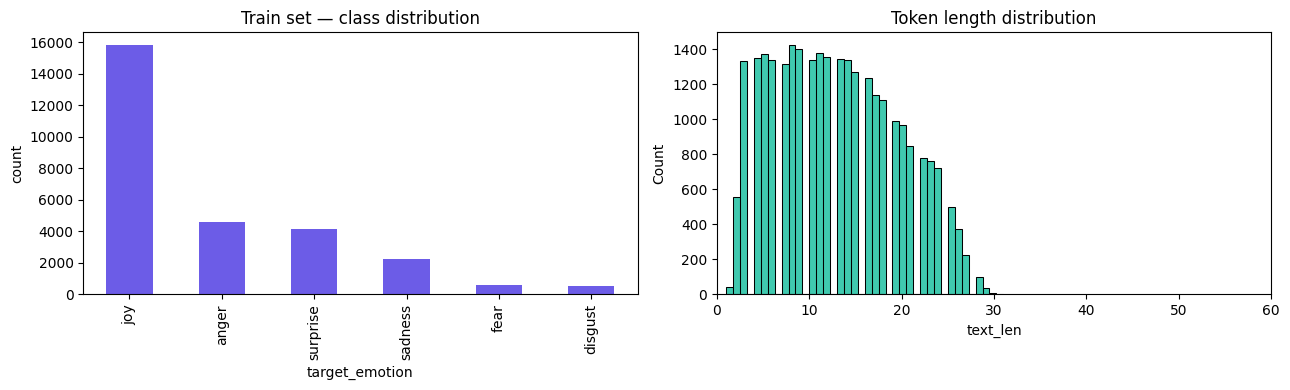

target_emotion
joy         0.566
anger       0.165
surprise    0.150
sadness     0.080
fear        0.020
disgust     0.019
Name: proportion, dtype: float64


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
train_df["target_emotion"].value_counts().plot(kind="bar", ax=ax[0], color="#6C5CE7")
ax[0].set_title("Train set — class distribution")
ax[0].set_ylabel("count")

train_df["text_len"] = train_df["text"].str.split().apply(len)
sns.histplot(train_df["text_len"], bins=40, ax=ax[1], color="#00B894")
ax[1].set_title("Token length distribution")
ax[1].set_xlim(0, 60)
plt.tight_layout()
plt.show()

print(train_df["target_emotion"].value_counts(normalize=True).round(3))


## 4. Text Cleaning & Tokenization

Basic cleaning (lowercase, strip URLs/mentions/extra punctuation), then Keras `Tokenizer` + padding for the LSTM/GRU/BiLSTM+Attention models. (DistilBERT gets its own tokenizer later — don't reuse this one for it.)


In [16]:
MAX_VOCAB = 20000
MAX_LEN = 40  # covers ~95th percentile of GoEmotions comment length

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\[name\]|\[religion\]", "", text)  # GoEmotions redaction tokens
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for d in (train_df, val_df, test_df):
    d["clean_text"] = d["text"].apply(clean_text)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

def to_padded(df):
    seqs = tokenizer.texts_to_sequences(df["clean_text"])
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(train_df)
X_val   = to_padded(val_df)
X_test  = to_padded(test_df)

y_train = to_categorical(train_df["label_id"], num_classes=len(TARGET_CLASSES))
y_val   = to_categorical(val_df["label_id"], num_classes=len(TARGET_CLASSES))
y_test  = to_categorical(test_df["label_id"], num_classes=len(TARGET_CLASSES))

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print("Vocab size used:", VOCAB_SIZE)
print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)


Vocab size used: 20000
X_train shape: (27950, 40) | y_train shape: (27950, 6)


## 5. Pre-trained GloVe Embeddings

We use **GloVe 100d** (smaller & faster than 300d, still a solid boost over random init).


In [17]:
EMBED_DIM = 100

# Downloads glove.6B.zip (~822MB, contains 50/100/200/300d files) — first run only
!wget -q -nc http://nlp.stanford.edu/data/glove.6B.zip
!unzip -n -q glove.6B.zip glove.6B.100d.txt


In [18]:
def load_glove_embeddings(path, tokenizer, vocab_size, embed_dim):
    embeddings_index = {}
    with open(path, encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vec = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = vec

    embedding_matrix = np.zeros((vocab_size, embed_dim))
    hits, misses = 0, 0
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            hits += 1
        else:
            misses += 1
    print(f"GloVe coverage: {hits} hits / {misses} misses "
          f"({hits / (hits + misses):.1%} of vocab found)")
    return embedding_matrix

embedding_matrix = load_glove_embeddings("glove.6B.100d.txt", tokenizer, VOCAB_SIZE, EMBED_DIM)


GloVe coverage: 17423 hits / 2576 misses (87.1% of vocab found)


In [22]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label_id"]
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for i, w in class_weight_dict.items():
    print(f"  {idx2label[i]:10s}: {w:.3f}")

Class weights:
  joy       : 0.294
  sadness   : 2.079
  anger     : 1.012
  fear      : 8.187
  surprise  : 1.115
  disgust   : 8.806


## 6. Build the Three Custom Architectures

All three share the same GloVe embedding layer for a fair comparison:
1. **LSTM** — baseline sequence model
2. **GRU** — lighter/faster alternative
3. **BiLSTM + Attention** — bidirectional context + learned attention weights (also gives us the heatmaps later)


In [29]:
NUM_CLASSES = len(TARGET_CLASSES)

def make_embedding_layer():
    return Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,
        name="glove_embedding",
    )

def build_lstm_model():
    inp = Input(shape=(MAX_LEN,), name="input")
    x = make_embedding_layer()(inp)
    x = LSTM(128, dropout=0.3)(x)   # recurrent_dropout removed — enables cuDNN + fixes instability
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(inp, out, name="LSTM")

def build_gru_model():
    inp = Input(shape=(MAX_LEN,), name="input")
    x = make_embedding_layer()(inp)
    x = GRU(128, dropout=0.3)(x)    # recurrent_dropout removed
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(inp, out, name="GRU")

In [30]:
class BahdanauAttention(Layer):
    """Additive attention over BiLSTM hidden states.
    Returns (context_vector, attention_weights) so we can plot heatmaps later.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = Dense(units)
        self.V = Dense(1)

    def call(self, hidden_states):
        # hidden_states: (batch, timesteps, hidden_dim)
        score = tf.nn.tanh(self.W(hidden_states))          # (batch, timesteps, units)
        attention_weights = tf.nn.softmax(self.V(score), axis=1)  # (batch, timesteps, 1)
        context_vector = attention_weights * hidden_states
        context_vector = tf.reduce_sum(context_vector, axis=1)   # (batch, hidden_dim)
        return context_vector, attention_weights


def build_bilstm_attention_model():
    inp = Input(shape=(MAX_LEN,), name="input")
    x = make_embedding_layer()(inp)
    hidden_states = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
    context_vector, attention_weights = BahdanauAttention(64, name="attention")(hidden_states)
    d = Dense(64, activation="relu")(context_vector)
    d = Dropout(0.3)(d)
    out = Dense(NUM_CLASSES, activation="softmax")(d)

    # Two models: one for training (loss on `out` only), one for inference that also exposes attention weights
    train_model = Model(inp, out, name="BiLSTM_Attention")
    attn_model  = Model(inp, [out, attention_weights], name="BiLSTM_Attention_with_weights")
    return train_model, attn_model


### 6.1 Compile & Train All Three

In [33]:
# Cap extreme class weights to avoid destabilizing GRU training
# (fear=8.19, disgust=8.81 were too aggressive — capping at 5.0 keeps the balancing effect without the instability)
capped_class_weights = {i: min(w, 5.0) for i, w in class_weight_dict.items()}
print("Capped class weights:")
for i, w in capped_class_weights.items():
    print(f"  {idx2label[i]:10s}: {w:.3f}")

def compile_and_train(model, name, epochs=6, batch_size=64, class_weight=None, lr=0.001):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        class_weight=class_weight,
        verbose=1,
    )
    model.save(f"{name}_model.h5")
    return history

histories = {}
trained_models = {}

lstm_model = build_lstm_model()
histories["LSTM"] = compile_and_train(lstm_model, "lstm", class_weight=capped_class_weights)
trained_models["LSTM"] = lstm_model

# GRU gets a lower learning rate — it's more sensitive to the class-weighted loss landscape
gru_model = build_gru_model()
histories["GRU"] = compile_and_train(gru_model, "gru", class_weight=capped_class_weights, lr=0.0005)
trained_models["GRU"] = gru_model

bilstm_attn_model, bilstm_attn_infer_model = build_bilstm_attention_model()
histories["BiLSTM+Attention"] = compile_and_train(bilstm_attn_model, "bilstm_attention", class_weight=capped_class_weights)
trained_models["BiLSTM+Attention"] = bilstm_attn_model


Capped class weights:
  joy       : 0.294
  sadness   : 2.079
  anger     : 1.012
  fear      : 5.000
  surprise  : 1.115
  disgust   : 5.000
Epoch 1/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2728 - loss: 1.5056 - val_accuracy: 0.5340 - val_loss: 1.4754
Epoch 2/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4056 - loss: 1.3816 - val_accuracy: 0.4506 - val_loss: 1.3948
Epoch 3/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4833 - loss: 1.2773 - val_accuracy: 0.5946 - val_loss: 1.0941
Epoch 4/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5464 - loss: 1.1657 - val_accuracy: 0.6197 - val_loss: 1.0278
Epoch 5/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5815 - loss: 1.0913 - val_accuracy: 0.6647 - val_loss: 0.9842
Epoch 6/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5986 - loss: 1.0453 - val_accuracy: 0.6502 - val_loss: 0.9321


Epoch 1/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.1836 - loss: 1.5270 - val_accuracy: 0.1423 - val_loss: 1.7079
Epoch 2/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1959 - loss: 1.5242 - val_accuracy: 0.1697 - val_loss: 1.6810
Epoch 3/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2059 - loss: 1.5242 - val_accuracy: 0.0749 - val_loss: 1.6983
Epoch 4/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2352 - loss: 1.5192 - val_accuracy: 0.3646 - val_loss: 1.6141
Epoch 5/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3963 - loss: 1.3686 - val_accuracy: 0.4438 - val_loss: 1.3931
Epoch 6/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4400 - loss: 1.2754 - val_accuracy: 0.4984 - val_loss: 1.1782


Epoch 1/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4758 - loss: 1.3361 - val_accuracy: 0.6223 - val_loss: 1.0304
Epoch 2/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5947 - loss: 1.0199 - val_accuracy: 0.6490 - val_loss: 0.9472
Epoch 3/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6218 - loss: 0.9391 - val_accuracy: 0.6436 - val_loss: 0.9769
Epoch 4/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6338 - loss: 0.8955 - val_accuracy: 0.6413 - val_loss: 0.9939
Epoch 5/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6458 - loss: 0.8733 - val_accuracy: 0.6633 - val_loss: 0.9228
Epoch 6/6
437/437 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6571 - loss: 0.8478 - val_accuracy: 0.6607 - val_loss: 0.9300


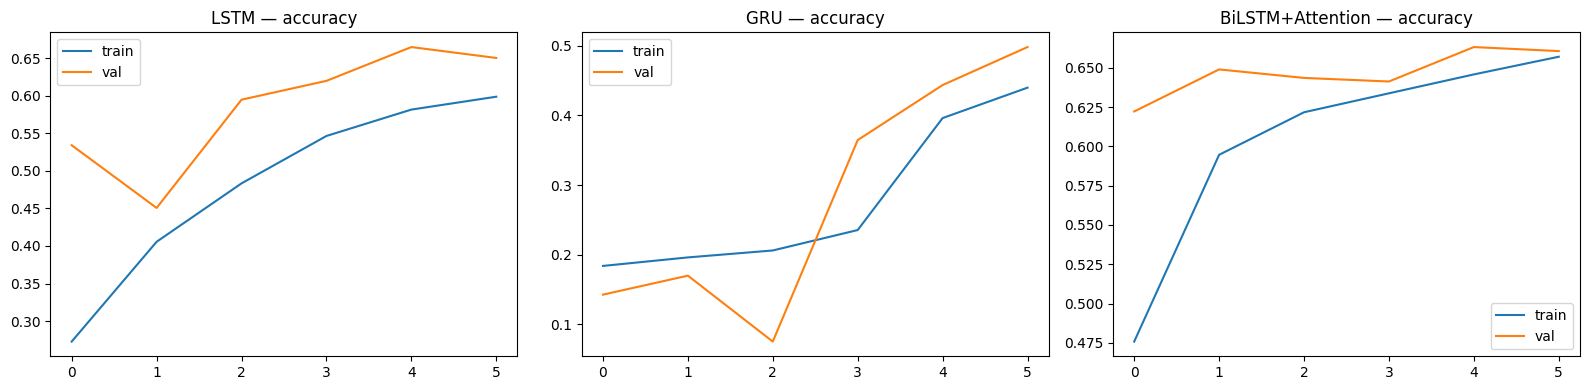

In [34]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history["accuracy"], label="train")
    ax.plot(hist.history["val_accuracy"], label="val")
    ax.set_title(f"{name} — accuracy")
    ax.legend()
plt.tight_layout()
plt.show()


## 7. Evaluation: Accuracy, Macro F1, Per-Class Precision/Recall, Confusion Matrix

Same evaluation function reused for every model so comparisons are apples-to-apples.


=== LSTM ===
Accuracy: 0.6429 | Macro F1: 0.5647

              precision    recall  f1-score   support

         joy      0.902     0.710     0.794      1938
     sadness      0.553     0.608     0.579       273
       anger      0.595     0.368     0.455       611
        fear      0.531     0.706     0.606        85
    surprise      0.356     0.745     0.482       538
     disgust      0.468     0.474     0.471        78

    accuracy                          0.643      3523
   macro avg      0.568     0.602     0.565      3523
weighted avg      0.720     0.643     0.659      3523



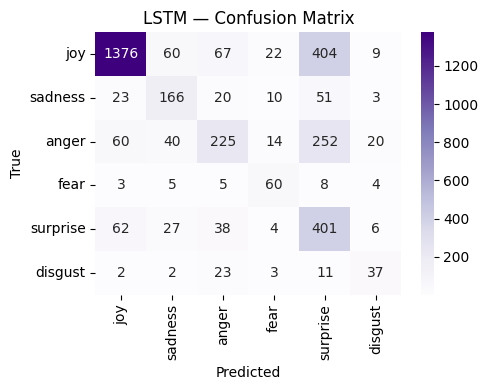

=== GRU ===
Accuracy: 0.5055 | Macro F1: 0.3551

              precision    recall  f1-score   support

         joy      0.871     0.605     0.714      1938
     sadness      0.312     0.538     0.395       273
       anger      0.315     0.129     0.183       611
        fear      0.265     0.635     0.374        85
    surprise      0.264     0.602     0.367       538
     disgust      0.200     0.064     0.097        78

    accuracy                          0.506      3523
   macro avg      0.371     0.429     0.355      3523
weighted avg      0.609     0.506     0.522      3523



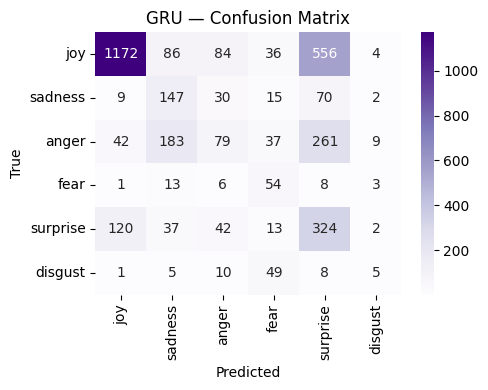

=== BiLSTM+Attention ===
Accuracy: 0.6585 | Macro F1: 0.5889

              precision    recall  f1-score   support

         joy      0.939     0.680     0.789      1938
     sadness      0.520     0.630     0.570       273
       anger      0.507     0.558     0.532       611
        fear      0.466     0.800     0.589        85
    surprise      0.436     0.686     0.533       538
     disgust      0.424     0.679     0.522        78

    accuracy                          0.659      3523
   macro avg      0.549     0.672     0.589      3523
weighted avg      0.732     0.659     0.677      3523



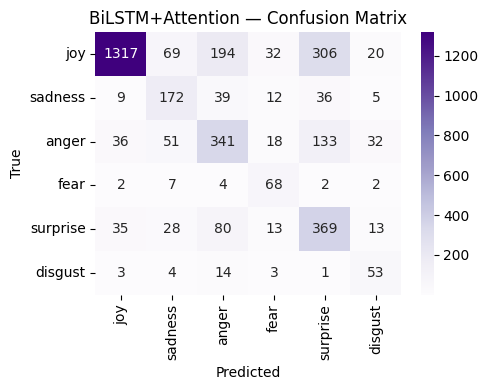

In [35]:
def evaluate_model(model, X, y_true_onehot, name):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.title(f"{name} — Confusion Matrix")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": acc, "macro_f1": macro_f1}

results = []
for name, model in trained_models.items():
    results.append(evaluate_model(model, X_test, y_test, name))


## 8. Attention Heatmaps — Which Words Drove the Prediction?

Uses the inference variant of the BiLSTM+Attention model that also returns per-token attention weights.


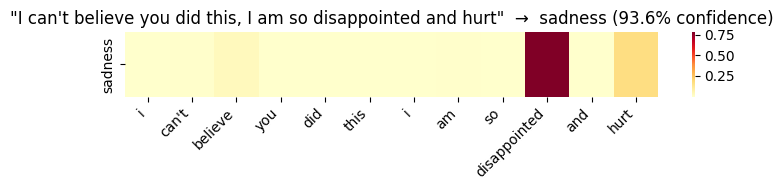

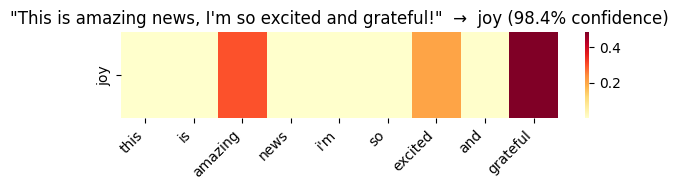

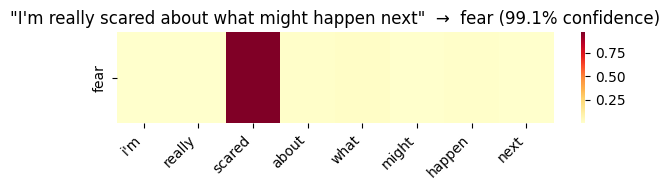

In [36]:
def plot_attention(text, model=bilstm_attn_infer_model, tokenizer=tokenizer, max_len=MAX_LEN):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    preds, attn_weights = model.predict(padded, verbose=0)
    pred_class = idx2label[np.argmax(preds[0])]
    confidence = np.max(preds[0])

    tokens = cleaned.split()[:max_len]
    weights = attn_weights[0, :len(tokens), 0]
    weights = weights / (weights.sum() + 1e-9)  # renormalize over real tokens only

    plt.figure(figsize=(max(6, len(tokens) * 0.6), 2))
    sns.heatmap([weights], annot=False, cmap="YlOrRd",
                xticklabels=tokens, yticklabels=[pred_class], cbar=True)
    plt.title(f'"{text}"  →  {pred_class} ({confidence:.1%} confidence)')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Try a few examples
plot_attention("I can't believe you did this, I am so disappointed and hurt")
plot_attention("This is amazing news, I'm so excited and grateful!")
plot_attention("I'm really scared about what might happen next")


## 9. Fine-tune DistilBERT (HuggingFace Trainer API)

Uses the *original* text (not the Keras-tokenized version) with the HF `AutoTokenizer`, then fine-tunes `distilbert-base-uncased` via `Trainer`.


In [37]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset
import evaluate as hf_evaluate

MODEL_NAME = "distilbert-base-uncased"
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df):
    return Dataset.from_pandas(df[["text", "label_id"]].rename(columns={"label_id": "label"}))

hf_train = to_hf_dataset(train_df)
hf_val   = to_hf_dataset(val_df)
hf_test  = to_hf_dataset(test_df)

def tokenize_fn(batch):
    return hf_tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

hf_train = hf_train.map(tokenize_fn, batched=True)
hf_val   = hf_val.map(tokenize_fn, batched=True)
hf_test  = hf_test.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/27950 [00:00<?, ? examples/s]

Map:   0%|          | 0/3513 [00:00<?, ? examples/s]

Map:   0%|          | 0/3523 [00:00<?, ? examples/s]

In [39]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES, id2label=idx2label, label2id=label2idx
)

accuracy_metric = hf_evaluate.load("accuracy")
f1_metric = hf_evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

training_args = TrainingArguments(
    output_dir="./distilbert_emotion",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    processing_class=hf_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.542926,0.509373,0.831198,0.721698
2,0.387510,0.515248,0.832906,0.725938
3,0.383540,0.548729,0.832337,0.727583


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5241, training_loss=0.4586688167060338, metrics={'train_runtime': 342.2279, 'train_samples_per_second': 245.012, 'train_steps_per_second': 15.314, 'total_flos': 733016652662808.0, 'train_loss': 0.4586688167060338, 'epoch': 3.0})

In [40]:
test_metrics = trainer.evaluate(hf_test)
print(test_metrics)

# Save for deployment
trainer.save_model("./distilbert_emotion_final")
hf_tokenizer.save_pretrained("./distilbert_emotion_final")

results.append({
    "model": "DistilBERT",
    "accuracy": test_metrics["eval_accuracy"],
    "macro_f1": test_metrics["eval_macro_f1"],
})


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.383540,0.599489,3,0.819756,0.711364


{'eval_loss': 0.5994892716407776, 'eval_accuracy': 0.819755889866591, 'eval_macro_f1': 0.7113638276392127}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 10. Final Model Comparison

              model  accuracy  macro_f1
0        DistilBERT  0.819756  0.711364
1  BiLSTM+Attention  0.658530  0.588915
2              LSTM  0.642918  0.564658
3               GRU  0.505535  0.355061


/tmp/ipykernel_1012/2852515221.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model", y="macro_f1", palette="viridis")


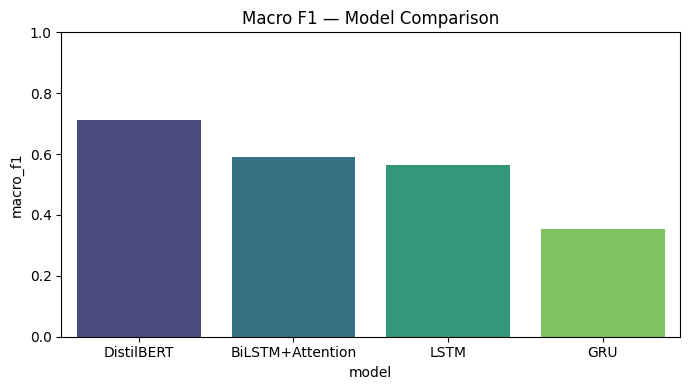


🏆 Best model: DistilBERT


In [41]:
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(results_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="model", y="macro_f1", palette="viridis")
plt.title("Macro F1 — Model Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

results_df.to_csv("model_comparison_results.csv", index=False)
print("\n🏆 Best model:", results_df.iloc[0]["model"])


## 11. Save Artifacts for the Gradio App

Save whichever model you pick as the deployed one (default: best by macro F1) + the tokenizer, so `app.py` can load them independently of this notebook.


In [42]:
import pickle

# Save the Keras tokenizer (needed if deploying LSTM/GRU/BiLSTM+Attention)
with open("tokenizer.pickle", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_map.json", "w") as f:
    json.dump(idx2label, f)

print("Saved: tokenizer.pickle, label_map.json")
print("DistilBERT model + tokenizer already saved at ./distilbert_emotion_final")
print("Keras models saved as lstm_model.h5, gru_model.h5, bilstm_attention_model.h5")


Saved: tokenizer.pickle, label_map.json
DistilBERT model + tokenizer already saved at ./distilbert_emotion_final
Keras models saved as lstm_model.h5, gru_model.h5, bilstm_attention_model.h5


---
## Next Step: Deployment

Head to **`app.py`** (in the same project folder) — a ready-to-run Gradio app that loads the best model and serves an interactive demo (dominant emotion + confidence bar chart across all 6 classes).

```bash
python app.py
```
